# Premier League Home Advantage Analysis

This project analyses Premier League match results from the 2021/22 to 2025/26 seasons to investigate the strength of home advantage.

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [42]:
data_dir = Path("../data")

files = {
    "2021/22": data_dir / "premier_league_2021_22.csv",
    "2022/23": data_dir / "premier_league_2022_23.csv",
    "2023/24": data_dir / "premier_league_2023_24.csv",
    "2024/25": data_dir / "premier_league_2024_25.csv",
    "2025/26": data_dir / "premier_league_2025_26.csv",
}

In [43]:
season_dataframes = []

for season, file_path in files.items():
    season_df = pd.read_csv(file_path)
    season_df["Season"] = season
    season_dataframes.append(season_df)

matches = pd.concat(season_dataframes, ignore_index=True)

In [44]:
print(matches.shape)
matches.head()

(1900, 163)


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,BMGMCA,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,E0,13/08/2021,20:00,Brentford,Arsenal,2,0,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,14/08/2021,12:30,Man United,Leeds,5,1,H,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,14/08/2021,15:00,Burnley,Brighton,1,2,A,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,14/08/2021,15:00,Chelsea,Crystal Palace,3,0,H,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,14/08/2021,15:00,Everton,Southampton,3,1,H,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data selection

The source files contain match statistics and betting-market variables. This analysis retains only the fields required to evaluate home advantage.

In [45]:
required_columns = [
    "Season",
    "Date",
    "HomeTeam",
    "AwayTeam",
    "FTHG",
    "FTAG",
    "FTR"
]

matches = matches[required_columns].copy()

matches.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,2021/22,13/08/2021,Brentford,Arsenal,2,0,H
1,2021/22,14/08/2021,Man United,Leeds,5,1,H
2,2021/22,14/08/2021,Burnley,Brighton,1,2,A
3,2021/22,14/08/2021,Chelsea,Crystal Palace,3,0,H
4,2021/22,14/08/2021,Everton,Southampton,3,1,H


In [46]:
print(matches.shape)
print(matches.columns.tolist())

(1900, 7)
['Season', 'Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR']


In [47]:
matches.groupby("Season").size()

Season
2021/22    380
2022/23    380
2023/24    380
2024/25    380
2025/26    380
dtype: int64

## Data cleaning and validation

The combined dataset is checked for missing values, incorrect data types, duplicate matches and invalid results before analysis.

In [48]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1900 entries, 0 to 1899
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Season    1900 non-null   object
 1   Date      1900 non-null   object
 2   HomeTeam  1900 non-null   object
 3   AwayTeam  1900 non-null   object
 4   FTHG      1900 non-null   int64 
 5   FTAG      1900 non-null   int64 
 6   FTR       1900 non-null   object
dtypes: int64(2), object(5)
memory usage: 104.0+ KB


In [49]:
matches.isna().sum()

Season      0
Date        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
dtype: int64

In [50]:
matches["Date"] = pd.to_datetime(
    matches["Date"],
    format="%d/%m/%Y"
)

In [51]:
matches.dtypes

Season              object
Date        datetime64[ns]
HomeTeam            object
AwayTeam            object
FTHG                 int64
FTAG                 int64
FTR                 object
dtype: object

In [52]:
duplicate_matches = matches.duplicated(
    subset=["Season", "Date", "HomeTeam", "AwayTeam"]
).sum()

print(f"Duplicate matches: {duplicate_matches}")

Duplicate matches: 0


In [53]:
matches["FTR"].value_counts()

FTR
H    839
A    607
D    454
Name: count, dtype: int64

In [54]:
valid_results = {"H", "D", "A"}
invalid_results = set(matches["FTR"].unique()) - valid_results

print(f"Invalid result codes: {invalid_results}")

Invalid result codes: set()


In [55]:
result_mismatches = matches[
    ((matches["FTHG"] > matches["FTAG"]) & (matches["FTR"] != "H")) |
    ((matches["FTHG"] == matches["FTAG"]) & (matches["FTR"] != "D")) |
    ((matches["FTHG"] < matches["FTAG"]) & (matches["FTR"] != "A"))
]

print(f"Score/result mismatches: {len(result_mismatches)}")

Score/result mismatches: 0


In [56]:
matches["GoalDifference"] = matches["FTHG"] - matches["FTAG"]

matches["Result"] = matches["FTR"].map({
    "H": "Home Win",
    "D": "Draw",
    "A": "Away Win"
})

In [57]:
matches["HomePoints"] = matches["FTR"].map({
    "H": 3,
    "D": 1,
    "A": 0
})

matches["AwayPoints"] = matches["FTR"].map({
    "H": 0,
    "D": 1,
    "A": 3
})

In [58]:
matches.head()

,Season,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,GoalDifference,Result,HomePoints,AwayPoints
0,2021/22,2021-08-13,Brentford,Arsenal,2,0,H,2,Home Win,3,0
1,2021/22,2021-08-14,Man United,Leeds,5,1,H,4,Home Win,3,0
2,2021/22,2021-08-14,Burnley,Brighton,1,2,A,-1,Away Win,0,3
3,2021/22,2021-08-14,Chelsea,Crystal Palace,3,0,H,3,Home Win,3,0
4,2021/22,2021-08-14,Everton,Southampton,3,1,H,2,Home Win,3,0


In [59]:
print(matches.shape)
print(matches.isna().sum())

(1900, 11)
Season            0
Date              0
HomeTeam          0
AwayTeam          0
FTHG              0
FTAG              0
FTR               0
GoalDifference    0
Result            0
HomePoints        0
AwayPoints        0
dtype: int64


In [60]:
matches.describe()

,Date,FTHG,FTAG,GoalDifference,HomePoints,AwayPoints
count,1900,1900.000000,1900.000000,1900.000000,1900.000000,1900.000000
mean,2024-01-07 09:32:12.631578880,1.597368,1.329474,0.267895,1.563684,1.197368
min,2021-08-13 00:00:00,0.000000,0.000000,-8.000000,0.000000,0.000000
25%,2022-10-16 00:00:00,1.000000,0.000000,-1.000000,0.000000,0.000000
50%,2023-12-30 00:00:00,1.000000,1.000000,0.000000,1.000000,1.000000
75%,2025-03-15 00:00:00,2.000000,2.000000,1.000000,3.000000,3.000000
max,2026-05-24 00:00:00,9.000000,8.000000,9.000000,3.000000,3.000000
std,NaN,1.318038,1.204203,1.899896,1.330030,1.296690


### Cleaning summary

The dataset contains 1,900 Premier League matches across five complete seasons. No missing values, duplicate fixtures, invalid result codes or score-result inconsistencies were identified. Dates were converted to a standard datetime format, and additional variables were created for goal difference, readable match results and league points.

## Overall match outcomes

This section compares the proportion of home wins, draws and away wins across all five Premier League seasons.

In [61]:
result_counts = matches["Result"].value_counts()

result_counts

Result
Home Win    839
Away Win    607
Draw        454
Name: count, dtype: int64

In [62]:
result_percentages = (
    matches["Result"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

result_percentages

Result
Home Win    44.2
Away Win    31.9
Draw        23.9
Name: proportion, dtype: float64

In [63]:
result_order = ["Home Win", "Draw", "Away Win"]

outcome_summary = pd.DataFrame({
    "Matches": result_counts.reindex(result_order),
    "Percentage": result_percentages.reindex(result_order)
})

outcome_summary

,Matches,Percentage
Result,,
Home Win,839,44.2
Draw,454,23.9
Away Win,607,31.9


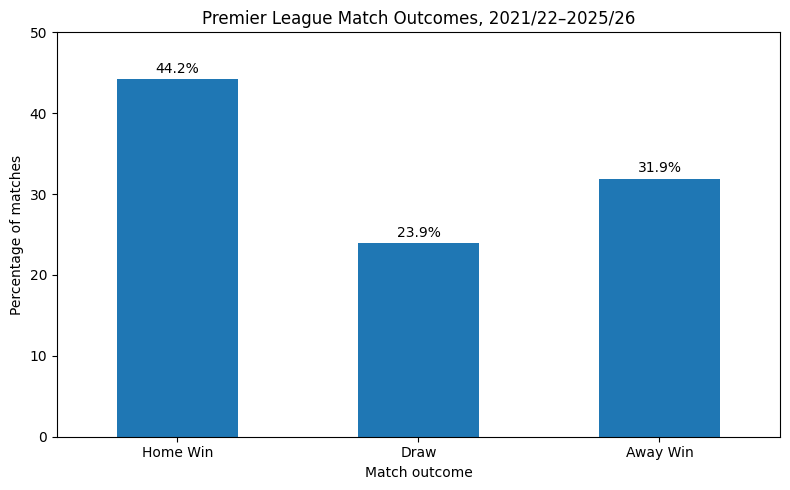

In [64]:
ax = outcome_summary["Percentage"].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Premier League Match Outcomes, 2021/22–2025/26")
ax.set_xlabel("Match outcome")
ax.set_ylabel("Percentage of matches")
ax.set_ylim(0, 50)

for index, value in enumerate(outcome_summary["Percentage"]):
    ax.text(index, value + 0.8, f"{value:.1f}%", ha="center")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Findings

Across the five seasons, home teams won 44.2% of matches, compared with 31.9% for away teams, a difference of 12.3 percentage points. Draws accounted for 23.9% of matches. This provides clear descriptive evidence of an overall home advantage.


## Goals scored at home and away

This section compares the average number of goals scored by home and away teams across the five seasons.

In [65]:
average_goals = pd.Series({
    "Home Goals": matches["FTHG"].mean(),
    "Away Goals": matches["FTAG"].mean()
}).round(2)

average_goals

Home Goals    1.60
Away Goals    1.33
dtype: float64

In [66]:
average_goal_difference = matches["GoalDifference"].mean()

print(f"Average home goal advantage: {average_goal_difference:.2f} goals per match")

Average home goal advantage: 0.27 goals per match


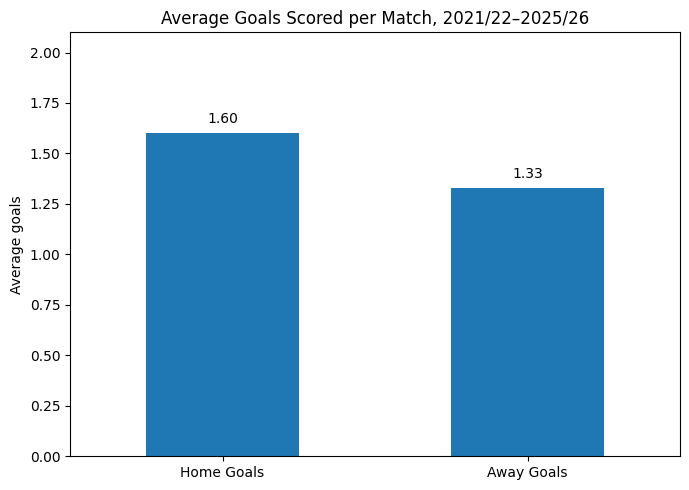

In [67]:
ax = average_goals.plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title("Average Goals Scored per Match, 2021/22–2025/26")
ax.set_xlabel("")
ax.set_ylabel("Average goals")
ax.set_ylim(0, average_goals.max() + 0.5)

for index, value in enumerate(average_goals):
    ax.text(index, value + 0.05, f"{value:.2f}", ha="center")

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/average_home_away_goals.png", dpi=300, bbox_inches="tight")
plt.show()

In [68]:
print(f"Average home goals: {matches['FTHG'].mean():.3f}")
print(f"Average away goals: {matches['FTAG'].mean():.3f}")
print(f"Average home goal advantage: {matches['GoalDifference'].mean():.3f}")

Average home goals: 1.597
Average away goals: 1.329
Average home goal advantage: 0.268


### Findings

Home teams scored an average of 1.60 goals per match, compared with 1.33 goals for away teams. This represents an average home goal advantage of approximately 0.27 goals per match. Together with the higher home-win percentage, this provides further descriptive evidence of home advantage across the five seasons.

## Home advantage by season

This section examines whether home advantage changed across the five Premier League seasons.

In [69]:
season_summary = (
    matches.groupby("Season")
    .agg(
        Matches=("FTR", "size"),
        HomeWins=("FTR", lambda results: (results == "H").sum()),
        AwayWins=("FTR", lambda results: (results == "A").sum()),
        AverageHomeGoals=("FTHG", "mean"),
        AverageAwayGoals=("FTAG", "mean"),
        AverageGoalDifference=("GoalDifference", "mean")
    )
)

season_summary["HomeWinPercentage"] = (
    season_summary["HomeWins"] / season_summary["Matches"] * 100
)

season_summary["AwayWinPercentage"] = (
    season_summary["AwayWins"] / season_summary["Matches"] * 100
)

season_summary = season_summary.round(2)

season_summary

,Matches,HomeWins,AwayWins,AverageHomeGoals,AverageAwayGoals,AverageGoalDifference,HomeWinPercentage,AwayWinPercentage
Season,,,,,,,,
2021/22,380,163,129,1.51,1.31,0.21,42.89,33.95
2022/23,380,184,109,1.63,1.22,0.42,48.42,28.68
2023/24,380,175,123,1.80,1.48,0.32,46.05,32.37
2024/25,380,155,132,1.51,1.42,0.09,40.79,34.74
2025/26,380,162,114,1.53,1.22,0.30,42.63,30.00


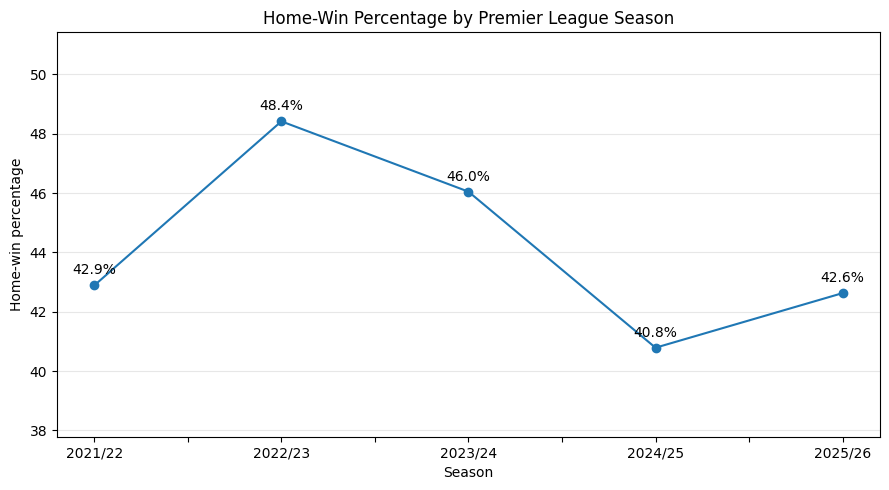

In [70]:
home_win_values = season_summary["HomeWinPercentage"]

ax = home_win_values.plot(
    kind="line",
    marker="o",
    figsize=(9, 5)
)

ax.set_title("Home-Win Percentage by Premier League Season")
ax.set_xlabel("Season")
ax.set_ylabel("Home-win percentage")
ax.set_ylim(
    home_win_values.min() - 3,
    home_win_values.max() + 3
)

for index, value in enumerate(home_win_values):
    ax.annotate(
        f"{value:.1f}%",
        xy=(index, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../images/home_win_percentage_by_season.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [71]:
plt.close("all")

### Findings

Home-win percentage varied across the five seasons rather than following a consistent upward or downward trend. It peaked at 48.4% in 2022/23 and fell to 40.8% in 2024/25 before recovering slightly to 42.6% in 2025/26. This suggests that home advantage remained present throughout the period, but its strength varied noticeably between seasons.

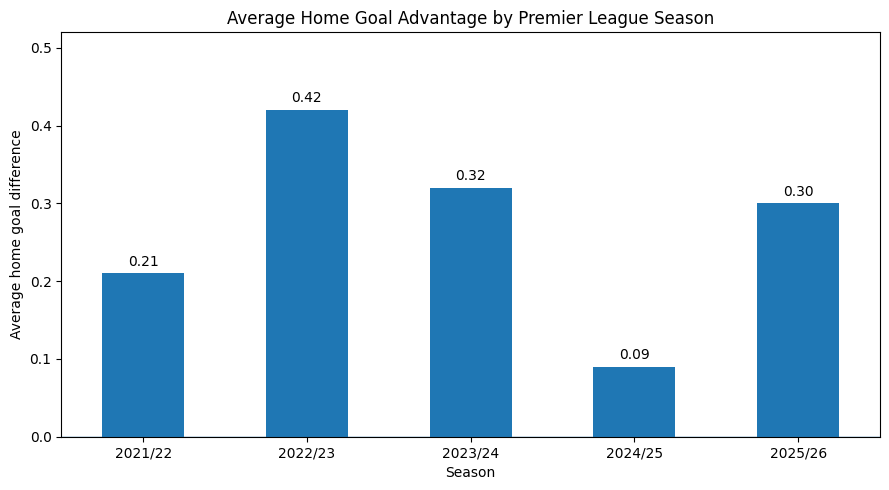

In [72]:
goal_difference_by_season = season_summary["AverageGoalDifference"]

ax = goal_difference_by_season.plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Average Home Goal Advantage by Premier League Season")
ax.set_xlabel("Season")
ax.set_ylabel("Average home goal difference")
ax.axhline(0, linewidth=1)

upper_limit = goal_difference_by_season.max() + 0.10
ax.set_ylim(0, upper_limit)

for index, value in enumerate(goal_difference_by_season):
    ax.text(
        index,
        value + 0.01,
        f"{value:.2f}",
        ha="center"
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    "../images/home_goal_advantage_by_season.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [73]:
season_summary[
    [
        "AverageHomeGoals",
        "AverageAwayGoals",
        "AverageGoalDifference"
    ]
]

,AverageHomeGoals,AverageAwayGoals,AverageGoalDifference
Season,,,
2021/22,1.51,1.31,0.21
2022/23,1.63,1.22,0.42
2023/24,1.80,1.48,0.32
2024/25,1.51,1.42,0.09
2025/26,1.53,1.22,0.30


### Findings

The average home goal advantage varied considerably between seasons. It was highest in 2022/23 at 0.42 goals per match and lowest in 2024/25 at just 0.09. The measure then recovered to 0.30 in 2025/26. This broadly mirrors the seasonal home-win percentages and suggests that the strength of home advantage fluctuated rather than following a consistent trend.

## Team home performance in 2025/26

This section compares each Premier League club’s home performance during the most recent season using points per match, win percentage and goal difference.

In [74]:
latest_season = matches[matches["Season"] == "2025/26"].copy()

print(latest_season.shape)

(380, 11)


In [75]:
home_team_summary = (
    latest_season.groupby("HomeTeam")
    .agg(
        HomeMatches=("HomeTeam", "size"),
        HomeWins=("FTR", lambda results: (results == "H").sum()),
        HomeDraws=("FTR", lambda results: (results == "D").sum()),
        HomeLosses=("FTR", lambda results: (results == "A").sum()),
        GoalsFor=("FTHG", "sum"),
        GoalsAgainst=("FTAG", "sum"),
        HomePoints=("HomePoints", "sum")
    )
)

In [76]:
home_team_summary["GoalDifference"] = (
    home_team_summary["GoalsFor"] - home_team_summary["GoalsAgainst"]
)

home_team_summary["PointsPerMatch"] = (
    home_team_summary["HomePoints"] / home_team_summary["HomeMatches"]
)

home_team_summary["HomeWinPercentage"] = (
    home_team_summary["HomeWins"] / home_team_summary["HomeMatches"] * 100
)

home_team_summary = home_team_summary.round({
    "PointsPerMatch": 2,
    "HomeWinPercentage": 1
})

In [77]:
home_team_summary = home_team_summary.sort_values(
    by=["PointsPerMatch", "GoalDifference"],
    ascending=[False, False]
)

home_team_summary

,HomeMatches,HomeWins,HomeDraws,HomeLosses,GoalsFor,GoalsAgainst,HomePoints,GoalDifference,PointsPerMatch,HomeWinPercentage
HomeTeam,,,,,,,,,,
Arsenal,19,15,2,2,41,11,47,30,2.47,78.9
Man City,19,14,3,2,45,14,45,31,2.37,73.7
Man United,19,13,3,3,39,24,42,15,2.21,68.4
Aston Villa,19,12,2,5,32,22,38,10,2.00,63.2
Liverpool,19,10,6,3,34,20,36,14,1.89,52.6
Fulham,19,11,2,6,30,20,35,10,1.84,57.9
Brighton,19,9,6,4,30,20,33,10,1.74,47.4
Sunderland,19,9,6,4,25,20,33,5,1.74,47.4
Brentford,19,8,8,3,33,21,32,12,1.68,42.1


In [78]:
home_team_summary["HomeMatches"].value_counts()

HomeMatches
19    20
Name: count, dtype: int64

In [79]:
home_team_summary[
    [
        "HomeMatches",
        "HomeWins",
        "HomeDraws",
        "HomeLosses",
        "GoalDifference",
        "HomePoints",
        "PointsPerMatch",
        "HomeWinPercentage"
    ]
].head()

,HomeMatches,HomeWins,HomeDraws,HomeLosses,GoalDifference,HomePoints,PointsPerMatch,HomeWinPercentage
HomeTeam,,,,,,,,
Arsenal,19,15,2,2,30,47,2.47,78.9
Man City,19,14,3,2,31,45,2.37,73.7
Man United,19,13,3,3,15,42,2.21,68.4
Aston Villa,19,12,2,5,10,38,2.00,63.2
Liverpool,19,10,6,3,14,36,1.89,52.6


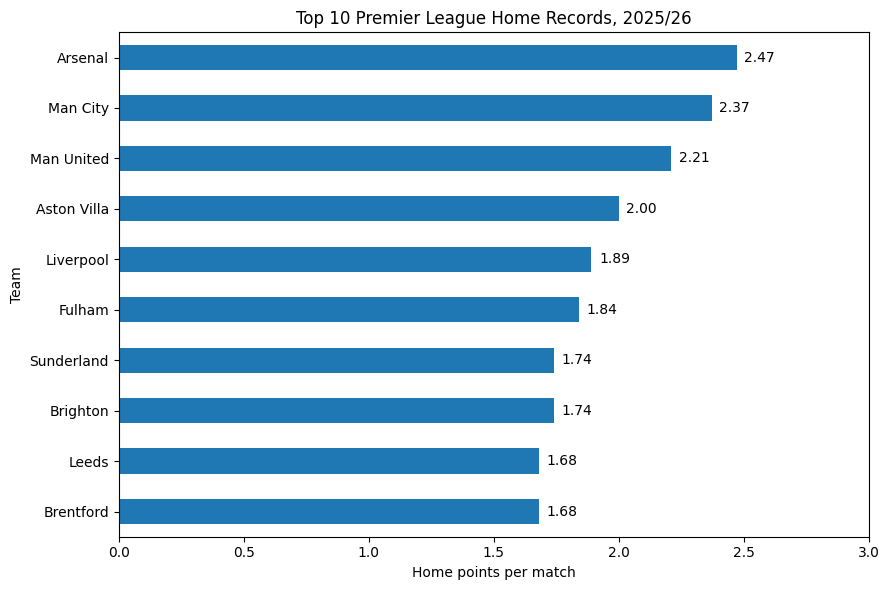

In [80]:
top_home_teams = home_team_summary.head(10)

ax = top_home_teams["PointsPerMatch"].sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

ax.set_title("Top 10 Premier League Home Records, 2025/26")
ax.set_xlabel("Home points per match")
ax.set_ylabel("Team")
ax.set_xlim(0, 3)

for index, value in enumerate(
    top_home_teams["PointsPerMatch"].sort_values()
):
    ax.text(
        value + 0.03,
        index,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.savefig(
    "../images/top_home_teams_2025_26.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Findings

Arsenal recorded the strongest home performance in 2025/26, averaging 2.47 points per home match. Manchester City ranked second at 2.37, while Manchester United recorded the third-best home record at 2.21 points per match. The gap between the leading clubs and the rest of the league suggests that home advantage was not distributed evenly, with the strongest teams extracting considerably more value from their home fixtures.

## Conclusion

This analysis examined 1,900 Premier League matches across five complete seasons from 2021/22 to 2025/26.

Home teams won 44.2% of matches, compared with 31.9% for away teams, and scored an average of 1.60 goals per match compared with 1.33 for away teams. This provides clear descriptive evidence of an overall home advantage.

However, the strength of that advantage varied between seasons. Home-win percentage peaked at 48.4% in 2022/23 and fell to 40.8% in 2024/25 before recovering slightly in 2025/26. Average home goal difference followed a similar pattern.

At club level, Arsenal recorded the strongest home performance in 2025/26, followed by Manchester City and Manchester United. Overall, the results suggest that home advantage remained present, but varied considerably across seasons and teams.